In [2]:
import torch
import torchvision

print(f'PyTorch    : {torch.__version__}')
print(f'Torchvision: {torchvision.__version__}')
print(f'CUDA ok    : {torch.cuda.is_available()}')
print(f'GPU        : {torch.cuda.get_device_name(0)}')

# Test che la GPU funzioni
x = torch.randn(3, 3).cuda()
y = x @ x.T
print(f'GPU test   : OK — shape {y.shape}')

PyTorch    : 2.3.0+cu121
Torchvision: 0.18.0+cu121
CUDA ok    : True
GPU        : Tesla P100-PCIE-16GB
GPU test   : OK — shape torch.Size([3, 3])


In [3]:
# =============================================================================
# SECTION 1 — GPU VERIFICATION
# Before running anything else, confirm that Kaggle has assigned a GPU to this
# session. If CUDA is not available, go to Settings → Accelerator → GPU T4.
# Training ViT-B/16 without a GPU would take ~8 hours per epoch — unusable.
# =============================================================================

import torch

print(f'CUDA available : {torch.cuda.is_available()}')

if torch.cuda.is_available():
    print(f'GPU            : {torch.cuda.get_device_name(0)}')
    print(f'GPU memory     : {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB')
else:
    print('WARNING: No GPU detected. Go to Settings → Accelerator → GPU T4 and restart.')

CUDA available : True
GPU            : Tesla P100-PCIE-16GB
GPU memory     : 17.1 GB


In [4]:
# =============================================================================
# SECTION 2 — IMPORTS & GLOBAL CONFIGURATION
# All third-party libraries are pre-installed in the Kaggle environment.
# Global constants are defined here so any change propagates to the whole
# notebook automatically — no need to hunt for hardcoded values.
# =============================================================================

import os
import copy
import time
import random

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset, random_split
from torchvision import datasets, transforms
from torchvision.models import vit_b_16, ViT_B_16_Weights
from sklearn.metrics import classification_report, confusion_matrix

# ── Reproducibility ──────────────────────────────────────────────────────────
# Fix all random seeds so results are identical across different runs.
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.deterministic = True

# ── Device ────────────────────────────────────────────────────────────────────
# Automatically use GPU if available, otherwise fall back to CPU.
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# ── Dataset paths ─────────────────────────────────────────────────────────────
# FER2013 folder structure: train/{emotion}/ and test/{emotion}/
DATA_ROOT = '/kaggle/input/datasets/msambare/fer2013'
TRAIN_DIR = os.path.join(DATA_ROOT, 'train')
TEST_DIR  = os.path.join(DATA_ROOT, 'test')

# ── Hyperparameters ───────────────────────────────────────────────────────────
IMG_SIZE       = 224    # ViT-B/16 and ResNet both expect 224x224 input
BATCH_SIZE     = 32     # Reduced to 32 for ViT (larger memory footprint than CNN)
NUM_WORKERS    = 2      # CPU workers for data loading on Kaggle free tier
VAL_SPLIT      = 0.15   # 15% of the training set is reserved for validation
NUM_EPOCHS     = 15     # Total training epochs
UNFREEZE_AFTER = 3      # Epochs of warm-up before unfreezing the backbone
LR_HEAD        = 1e-3   # Higher learning rate for the new classification head
LR_BACKBONE    = 1e-5   # Very low LR for the pretrained backbone (ViT is sensitive)
WEIGHT_DECAY   = 1e-4   # L2 regularization to prevent overfitting

# ── ImageNet normalization constants ──────────────────────────────────────────
# These values come from the ImageNet dataset on which ViT was pretrained.
# Using the same statistics ensures our inputs match what the model expects.
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]

# ── Output paths ──────────────────────────────────────────────────────────────
CKPT_PATH  = '/kaggle/working/fer_vit_best.pth'
FINAL_PATH = '/kaggle/working/fer_vit_final.pth'

print(f'Device  : {DEVICE}')
print(f'Config  : IMG={IMG_SIZE}, BATCH={BATCH_SIZE}, EPOCHS={NUM_EPOCHS}')

Device  : cuda
Config  : IMG=224, BATCH=32, EPOCHS=15


In [5]:
# =============================================================================
# SECTION 3 — DATA TRANSFORMS
# Transforms define how raw images are preprocessed before being fed to the
# model. Two separate pipelines are used:
#
#   train_transforms : includes data augmentation to artificially increase
#                      dataset variety and reduce overfitting.
#   val_transforms   : no augmentation — only the structural changes needed
#                      to match the model input format. Applied to both the
#                      validation and test sets.
#
# Key detail: FER2013 images are grayscale (1 channel). ViT-B/16 expects
# RGB (3 channels). Grayscale(num_output_channels=3) duplicates the single
# channel three times, making the image compatible with the pretrained model.
# =============================================================================

train_transforms = transforms.Compose([

    # Upsample from 48x48 (FER2013 native) to 224x224 (ViT expected input)
    transforms.Resize((IMG_SIZE, IMG_SIZE)),

    # Convert 1-channel grayscale to 3-channel RGB by replicating the channel
    transforms.Grayscale(num_output_channels=3),

    # Mirror the face horizontally with 50% probability — emotions are symmetric
    transforms.RandomHorizontalFlip(p=0.5),

    # Rotate up to 15 degrees to simulate head tilt variation
    transforms.RandomRotation(degrees=15),

    # Randomly vary brightness and contrast to simulate different lighting conditions
    transforms.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.1),

    # Convert PIL image to PyTorch float tensor and scale pixels from [0,255] to [0,1]
    transforms.ToTensor(),

    # Standardize pixel values using ImageNet mean and std
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),

    # Randomly mask a small rectangular region — forces the model to not rely
    # on a single facial feature (e.g., only the mouth)
    transforms.RandomErasing(p=0.2, scale=(0.02, 0.1)),
])

val_transforms = transforms.Compose([

    # Same resize as training
    transforms.Resize((IMG_SIZE, IMG_SIZE)),

    # Same grayscale-to-RGB conversion as training
    transforms.Grayscale(num_output_channels=3),

    # Convert to tensor
    transforms.ToTensor(),

    # Same normalization as training — consistency is critical
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])

print('Transforms defined.')

Transforms defined.


In [6]:
# =============================================================================
# SECTION 4 — DATASET LOADING, TRAIN/VAL SPLIT & DATALOADERS
#
# ImageFolder automatically assigns integer labels based on subfolder names
# (alphabetical order). No CSV parsing is needed.
#
# The training set is then split into train (85%) and validation (15%).
# A custom wrapper (SubsetWithTransform) is used to apply val_transforms
# to the validation subset independently from the training transforms.
#
# DataLoaders wrap the datasets and handle batching, shuffling and
# parallel data loading during training.
# =============================================================================

# Load the full training folder — applies train_transforms by default
full_train_ds = datasets.ImageFolder(root=TRAIN_DIR, transform=train_transforms)
test_ds       = datasets.ImageFolder(root=TEST_DIR,  transform=val_transforms)

# Class names are derived directly from the subfolder names
CLASS_NAMES = full_train_ds.classes
NUM_CLASSES = len(CLASS_NAMES)
print(f'Classes ({NUM_CLASSES}): {CLASS_NAMES}')
print(f'Full train+val  : {len(full_train_ds)} images')
print(f'Test            : {len(test_ds)} images')

# ── Train / Validation split ──────────────────────────────────────────────────
val_size   = int(len(full_train_ds) * VAL_SPLIT)
train_size = len(full_train_ds) - val_size

train_subset, val_subset = random_split(
    full_train_ds,
    [train_size, val_size],
    generator=torch.Generator().manual_seed(SEED)
)

# ── Custom wrapper to apply val_transforms to the validation subset ───────────
# random_split keeps the parent dataset's transform, so we override it here.
# Without this, the validation set would receive augmentation — which is wrong.
class SubsetWithTransform(Dataset):
    def __init__(self, subset, transform):
        self.subset    = subset
        self.transform = transform

    def __len__(self):
        return len(self.subset)

    def __getitem__(self, idx):
        # Retrieve the file path and label from the parent ImageFolder
        img_path, label = self.subset.dataset.samples[self.subset.indices[idx]]
        img = Image.open(img_path).convert('RGB')
        return self.transform(img), label

# Wrap the validation subset with clean val_transforms
val_ds = SubsetWithTransform(val_subset, val_transforms)

print(f'\nSplit — Train: {train_size} | Val: {val_size} | Test: {len(test_ds)}')

# ── DataLoaders ───────────────────────────────────────────────────────────────
# shuffle=True only for training — order should be randomized each epoch
# pin_memory=True speeds up CPU→GPU transfers
train_loader = DataLoader(train_subset, batch_size=BATCH_SIZE, shuffle=True,
                          num_workers=NUM_WORKERS, pin_memory=True)
val_loader   = DataLoader(val_ds,       batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=NUM_WORKERS, pin_memory=True)
test_loader  = DataLoader(test_ds,      batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=NUM_WORKERS, pin_memory=True)

print(f'Batches — Train: {len(train_loader)} | Val: {len(val_loader)} | Test: {len(test_loader)}')

Classes (7): ['angry', 'disgust', 'fear', 'happy', 'neutral', 'sad', 'surprise']
Full train+val  : 28709 images
Test            : 7178 images

Split — Train: 24403 | Val: 4306 | Test: 7178
Batches — Train: 763 | Val: 135 | Test: 225


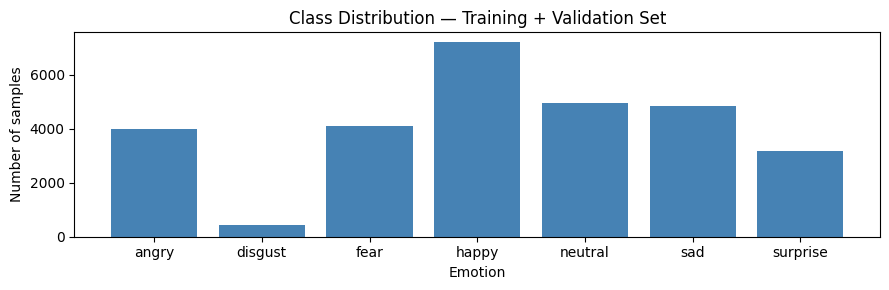

Class weights (higher = rarer class):
  angry      0.480
  disgust    4.398
  fear       0.468
  happy      0.266
  neutral    0.386
  sad        0.397
  surprise   0.605


In [7]:
# =============================================================================
# SECTION 5 — CLASS DISTRIBUTION ANALYSIS & CLASS WEIGHTS
#
# FER2013 is imbalanced: 'happy' has ~3x more samples than 'disgust'.
# Without correction, the model learns to predict the majority class more
# often, which is a problem for clinical applications where rare expressions
# (e.g., fear) are equally important to detect.
#
# Solution: compute inverse-frequency weights and pass them to CrossEntropyLoss.
# Rare classes receive a higher penalty when misclassified.
# =============================================================================

# Count how many samples belong to each emotion class
counts = np.zeros(NUM_CLASSES, dtype=int)
for _, label in full_train_ds:
    counts[label] += 1

# Plot the class distribution
plt.figure(figsize=(9, 3))
plt.bar(CLASS_NAMES, counts, color='steelblue')
plt.title('Class Distribution — Training + Validation Set')
plt.xlabel('Emotion')
plt.ylabel('Number of samples')
plt.tight_layout()
plt.savefig('/kaggle/working/class_distribution.png', dpi=150)
plt.show()

# Compute inverse-frequency weights
# Formula: weight_i = 1 / count_i, then normalize so the mean weight = 1
weights      = 1.0 / counts.astype(float)
weights      = weights / weights.sum() * NUM_CLASSES
CLASS_WEIGHTS = torch.tensor(weights, dtype=torch.float32)

print('Class weights (higher = rarer class):')
for name, w in zip(CLASS_NAMES, weights):
    print(f'  {name:<10} {w:.3f}')

In [8]:
# =============================================================================
# SECTION 6 — VISION TRANSFORMER MODEL DEFINITION
#
# We use ViT-B/16 (Base, patch size 16) pretrained on ImageNet.
# Architecture overview:
#   - Input image is divided into 14x14 = 196 patches of 16x16 pixels
#   - Each patch is linearly projected into a 768-dimensional embedding
#   - A special [CLS] token is prepended to the sequence
#   - 12 Transformer encoder layers process the sequence with self-attention
#   - The final [CLS] token is passed to the classification head
#
# Transfer learning strategy (two-phase):
#   Phase 1 — Warm-up (epochs 1 to UNFREEZE_AFTER):
#     Only the new classification head is trained. The pretrained backbone
#     is frozen. This prevents the random head from destroying the learned
#     ImageNet features in the early, noisy gradient updates.
#
#   Phase 2 — Fine-tuning (epochs UNFREEZE_AFTER+1 to NUM_EPOCHS):
#     All layers are unfrozen and trained together, but the backbone uses
#     a much lower learning rate (LR_BACKBONE) to preserve its knowledge.
# =============================================================================

def build_vit(num_classes: int) -> nn.Module:
    """
    Load ViT-B/16 pretrained on ImageNet and replace the classification
    head with a new head for `num_classes` emotion categories.
    """
    # Download pretrained weights from PyTorch Hub (requires internet enabled)
    model = vit_b_16(weights=ViT_B_16_Weights.IMAGENET1K_V1)

    # The original head outputs 1000 classes (ImageNet)
    # We replace it with: Dropout → Linear(768, num_classes)
    in_features = model.heads.head.in_features   # always 768 for ViT-B
    model.heads.head = nn.Sequential(
        nn.Dropout(p=0.3),                        # regularization
        nn.Linear(in_features, num_classes)        # output: 7 emotion scores
    )
    return model


def freeze_vit_backbone(model: nn.Module):
    """Freeze all layers except the classification head (warm-up phase)."""
    for name, param in model.named_parameters():
        if 'heads' not in name:
            param.requires_grad = False


def unfreeze_vit_backbone(model: nn.Module):
    """Unfreeze all layers for full fine-tuning."""
    for param in model.parameters():
        param.requires_grad = True


# Build the model and move it to GPU
model = build_vit(NUM_CLASSES).to(DEVICE)

# Start with backbone frozen — only the head will be trained initially
freeze_vit_backbone(model)

# Report parameter counts
trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
total     = sum(p.numel() for p in model.parameters())
print(f'Trainable parameters : {trainable:>12,}  (head only — backbone frozen)')
print(f'Total parameters     : {total:>12,}')
print(f'Backbone parameters  : {total - trainable:>12,}  (frozen until epoch {UNFREEZE_AFTER + 1})')

Trainable parameters :        5,383  (head only — backbone frozen)
Total parameters     :   85,804,039
Backbone parameters  :   85,798,656  (frozen until epoch 4)


In [9]:
# =============================================================================
# SECTION 7 — LOSS FUNCTION, OPTIMIZER & LEARNING RATE SCHEDULER
#
# Loss — CrossEntropyLoss with:
#   - class_weights : penalizes errors on rare classes more heavily
#   - label_smoothing=0.1 : prevents overconfident predictions by assigning
#     a small probability to non-target classes (regularization trick)
#
# Optimizer — AdamW with two parameter groups:
#   - model.heads : LR_HEAD (1e-3) — higher, this layer trains from scratch
#   - backbone    : LR_BACKBONE (1e-5) — very low, preserves pretrained features
#
# Scheduler — CosineAnnealingLR:
#   Smoothly decreases the learning rate following a cosine curve over all
#   epochs. This avoids oscillations near convergence and typically improves
#   final accuracy by a few percentage points.
# =============================================================================

# Weighted cross-entropy loss to handle class imbalance
criterion = nn.CrossEntropyLoss(
    weight=CLASS_WEIGHTS.to(DEVICE),
    label_smoothing=0.1
)

# AdamW optimizer with differential learning rates
# The backbone group is defined even though it's frozen during warm-up —
# the optimizer will start updating it automatically after unfreeze
optimizer = optim.AdamW([
    {'params': model.heads.parameters(),
     'lr': LR_HEAD},
    {'params': [p for n, p in model.named_parameters() if 'heads' not in n],
     'lr': LR_BACKBONE},
], weight_decay=WEIGHT_DECAY)

# Cosine annealing: LR starts high, decreases smoothly to eta_min
scheduler = optim.lr_scheduler.CosineAnnealingLR(
    optimizer, T_max=NUM_EPOCHS, eta_min=1e-7
)

print('Loss     : CrossEntropyLoss (weighted, label_smoothing=0.1)')
print('Optimizer: AdamW (head LR=1e-3, backbone LR=1e-5)')
print('Scheduler: CosineAnnealingLR')

Loss     : CrossEntropyLoss (weighted, label_smoothing=0.1)
Optimizer: AdamW (head LR=1e-3, backbone LR=1e-5)
Scheduler: CosineAnnealingLR


In [10]:
# Fix per AcceleratorError — forza PyTorch a usare un backend compatibile
import torch
import os

# Disabilita TF32 che causa problemi con alcune GPU Kaggle
torch.backends.cuda.matmul.allow_tf32 = False
torch.backends.cudnn.allow_tf32 = False

# Forza la sincronizzazione degli errori CUDA per debug più chiaro
os.environ['CUDA_LAUNCH_BLOCKING'] = '1'

print(f'PyTorch version : {torch.__version__}')
print(f'CUDA version    : {torch.version.cuda}')
print(f'GPU             : {torch.cuda.get_device_name(0)}')

PyTorch version : 2.3.0+cu121
CUDA version    : 12.1
GPU             : Tesla P100-PCIE-16GB


In [11]:
# =============================================================================
# SECTION 8 — TRAINING LOOP
#
# Each epoch consists of:
#   1. Training pass  : forward pass, compute loss, backprop, update weights
#   2. Validation pass: forward pass only (no gradient updates), measure accuracy
#   3. Scheduler step : update learning rate according to cosine schedule
#   4. Checkpointing  : save model if validation accuracy improved
#
# At epoch UNFREEZE_AFTER+1, the backbone is unfrozen and full fine-tuning
# begins. Gradient clipping (max_norm=1.0) is applied during training to
# prevent exploding gradients, which are common in Transformer models.
#
# The best model (highest val accuracy) is saved during training and will
# be loaded for final evaluation in Section 10.
# =============================================================================

def run_epoch(model, loader, criterion, optimizer=None, train=True):
    """
    Run one full pass over `loader`.
    If train=True, perform backpropagation and update weights.
    Returns (average_loss, accuracy) for the epoch.
    """
    model.train() if train else model.eval()
    total_loss, correct, total = 0.0, 0, 0

    with torch.set_grad_enabled(train):
        for images, labels in loader:
            images, labels = images.to(DEVICE), labels.to(DEVICE)

            # Forward pass: compute predicted emotion scores
            logits = model(images)

            # Compute weighted cross-entropy loss
            loss = criterion(logits, labels)

            if train:
                optimizer.zero_grad()                                    # clear previous gradients
                loss.backward()                                          # compute new gradients
                nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)  # prevent exploding gradients
                optimizer.step()                                         # update weights

            # Accumulate metrics
            total_loss += loss.item() * images.size(0)
            correct    += (logits.argmax(dim=1) == labels).sum().item()
            total      += images.size(0)

    return total_loss / total, correct / total


# ── Training ──────────────────────────────────────────────────────────────────
history        = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}
best_val_acc   = 0.0
best_model_wts = copy.deepcopy(model.state_dict())

for epoch in range(1, NUM_EPOCHS + 1):
    t0 = time.time()

    # Phase 2 starts: unfreeze backbone for full fine-tuning
    if epoch == UNFREEZE_AFTER + 1:
        unfreeze_vit_backbone(model)
        total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
        print(f'\nEpoch {epoch}: backbone unfrozen — {total_params:,} parameters now training.')

    # Run training and validation passes
    tr_loss, tr_acc = run_epoch(model, train_loader, criterion, optimizer, train=True)
    vl_loss, vl_acc = run_epoch(model, val_loader,   criterion,            train=False)

    # Step the learning rate scheduler
    scheduler.step()

    # Record history for plotting
    history['train_loss'].append(tr_loss)
    history['val_loss'].append(vl_loss)
    history['train_acc'].append(tr_acc)
    history['val_acc'].append(vl_acc)

    elapsed = time.time() - t0
    print(f'Epoch {epoch:02d}/{NUM_EPOCHS} | '
          f'Train loss {tr_loss:.4f}  acc {tr_acc:.3f} | '
          f'Val loss {vl_loss:.4f}  acc {vl_acc:.3f} | '
          f'{elapsed:.0f}s')

    # Save checkpoint whenever validation accuracy improves
    if vl_acc > best_val_acc:
        best_val_acc   = vl_acc
        best_model_wts = copy.deepcopy(model.state_dict())
        torch.save({
            'epoch':         epoch,
            'model_state':   best_model_wts,
            'val_acc':       best_val_acc,
            'num_classes':   NUM_CLASSES,
            'class_names':   CLASS_NAMES,
            'architecture':  'vit_b_16',
            'img_size':      IMG_SIZE,
            'imagenet_mean': IMAGENET_MEAN,
            'imagenet_std':  IMAGENET_STD,
        }, CKPT_PATH)
        print(f'  >>> New best val acc: {best_val_acc:.4f} — checkpoint saved.')

print(f'\nTraining complete. Best val accuracy: {best_val_acc:.4f}')

Epoch 01/15 | Train loss 1.9253  acc 0.341 | Val loss 1.8179  acc 0.401 | 194s
  >>> New best val acc: 0.4006 — checkpoint saved.
Epoch 02/15 | Train loss 1.8495  acc 0.392 | Val loss 1.7906  acc 0.460 | 193s
  >>> New best val acc: 0.4596 — checkpoint saved.
Epoch 03/15 | Train loss 1.8454  acc 0.405 | Val loss 1.8311  acc 0.425 | 193s

Epoch 4: backbone unfrozen — 85,804,039 parameters now training.
Epoch 04/15 | Train loss 1.6848  acc 0.490 | Val loss 1.6017  acc 0.586 | 493s
  >>> New best val acc: 0.5857 — checkpoint saved.
Epoch 05/15 | Train loss 1.5331  acc 0.588 | Val loss 1.5230  acc 0.588 | 493s
  >>> New best val acc: 0.5880 — checkpoint saved.
Epoch 06/15 | Train loss 1.4572  acc 0.634 | Val loss 1.4796  acc 0.634 | 493s
  >>> New best val acc: 0.6340 — checkpoint saved.
Epoch 07/15 | Train loss 1.3925  acc 0.667 | Val loss 1.4738  acc 0.648 | 493s
  >>> New best val acc: 0.6482 — checkpoint saved.
Epoch 08/15 | Train loss 1.3454  acc 0.698 | Val loss 1.4539  acc 0.656 | 4

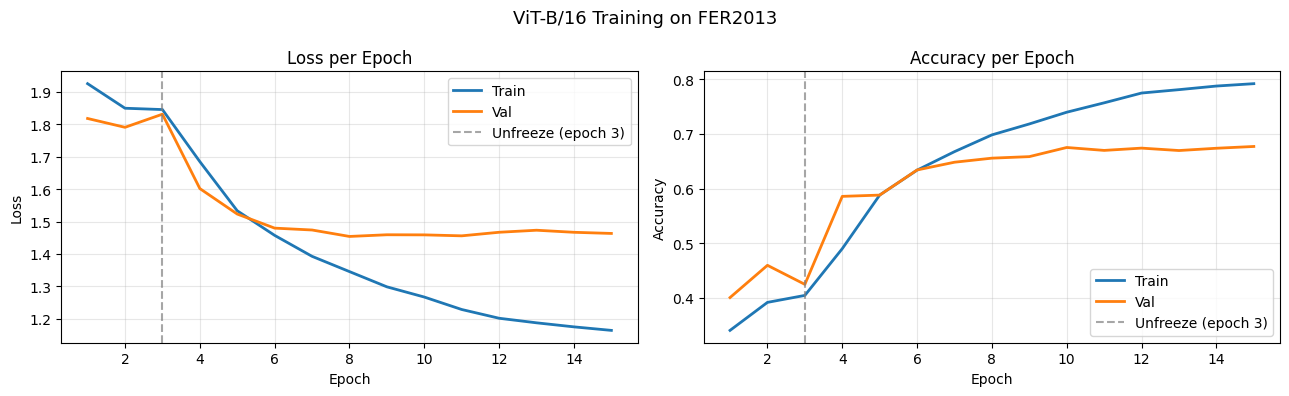

In [12]:
# =============================================================================
# SECTION 9 — TRAINING CURVES
#
# Visualize how loss and accuracy evolved across epochs for both the training
# and validation sets. The vertical dashed line marks the epoch where the
# backbone was unfrozen.
#
# What to look for:
#   - Loss should decrease steadily for both train and val
#   - Accuracy should increase for both
#   - A large gap between train and val curves = overfitting
#   - Val loss increasing while train loss decreases = overfitting
# =============================================================================

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4))
ep = range(1, NUM_EPOCHS + 1)

ax1.plot(ep, history['train_loss'], label='Train', linewidth=2)
ax1.plot(ep, history['val_loss'],   label='Val',   linewidth=2)
ax1.axvline(UNFREEZE_AFTER, color='gray', linestyle='--', alpha=0.7, label=f'Unfreeze (epoch {UNFREEZE_AFTER})')
ax1.set_title('Loss per Epoch')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss')
ax1.legend()
ax1.grid(alpha=0.3)

ax2.plot(ep, history['train_acc'], label='Train', linewidth=2)
ax2.plot(ep, history['val_acc'],   label='Val',   linewidth=2)
ax2.axvline(UNFREEZE_AFTER, color='gray', linestyle='--', alpha=0.7, label=f'Unfreeze (epoch {UNFREEZE_AFTER})')
ax2.set_title('Accuracy per Epoch')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Accuracy')
ax2.legend()
ax2.grid(alpha=0.3)

plt.suptitle('ViT-B/16 Training on FER2013', fontsize=13)
plt.tight_layout()
plt.savefig('/kaggle/working/training_curves_vit.png', dpi=150)
plt.show()

Loaded best checkpoint from epoch 15 (val acc: 0.6770)

--- Classification Report ---
              precision    recall  f1-score   support

       angry       0.62      0.61      0.61       958
     disgust       0.27      0.78      0.40       111
        fear       0.56      0.47      0.51      1024
       happy       0.91      0.84      0.87      1774
     neutral       0.64      0.66      0.65      1233
         sad       0.56      0.54      0.55      1247
    surprise       0.75      0.83      0.79       831

    accuracy                           0.67      7178
   macro avg       0.61      0.68      0.63      7178
weighted avg       0.68      0.67      0.67      7178



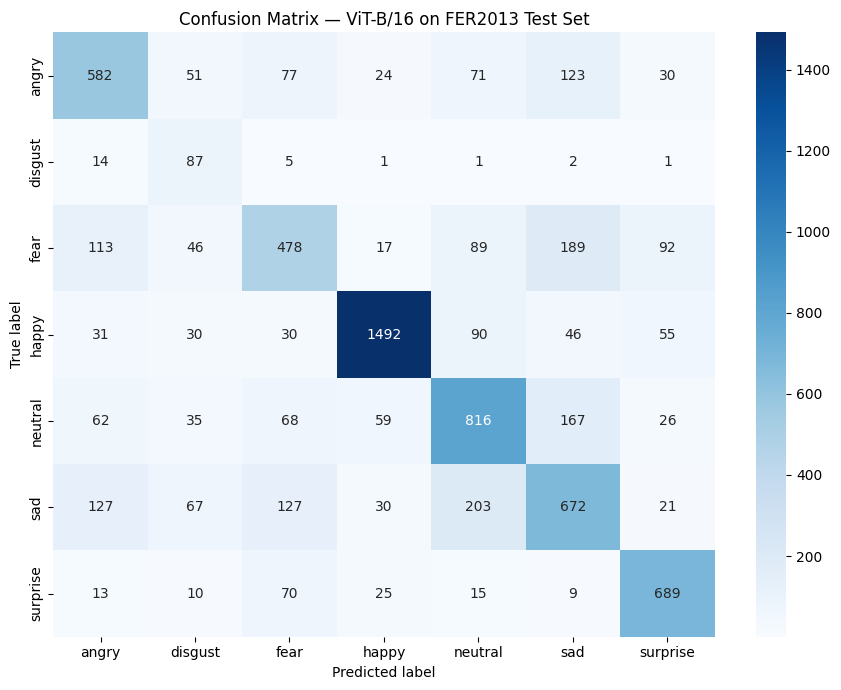

In [13]:
# =============================================================================
# SECTION 10 — TEST SET EVALUATION
#
# Load the best checkpoint (highest val accuracy) and evaluate it on the
# held-out test set. Two outputs are produced:
#
#   1. Classification report: per-class precision, recall, F1-score.
#      Useful for identifying which emotions are hardest to classify.
#      (Expected: Fear and Disgust will have the lowest F1 due to low sample count)
#
#   2. Confusion matrix: shows which emotions get confused with each other.
#      Clinically relevant — e.g., confusing Fear with Neutral is more
#      dangerous than confusing Happy with Neutral.
# =============================================================================

# Load the best checkpoint saved during training
ckpt = torch.load(CKPT_PATH, map_location=DEVICE)
model.load_state_dict(ckpt['model_state'])
model.eval()
print(f'Loaded best checkpoint from epoch {ckpt["epoch"]} (val acc: {ckpt["val_acc"]:.4f})')

# Run inference on the full test set
all_preds, all_labels = [], []
with torch.no_grad():
    for images, labels in test_loader:
        preds = model(images.to(DEVICE)).argmax(dim=1).cpu().numpy()
        all_preds.extend(preds)
        all_labels.extend(labels.numpy())

# Print per-class precision, recall, F1
print('\n--- Classification Report ---')
print(classification_report(all_labels, all_preds, target_names=CLASS_NAMES))

# Plot confusion matrix
cm = confusion_matrix(all_labels, all_preds)
fig, ax = plt.subplots(figsize=(9, 7))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES, ax=ax)
ax.set_xlabel('Predicted label')
ax.set_ylabel('True label')
ax.set_title('Confusion Matrix — ViT-B/16 on FER2013 Test Set')
plt.tight_layout()
plt.savefig('/kaggle/working/confusion_matrix_vit.png', dpi=150)
plt.show()